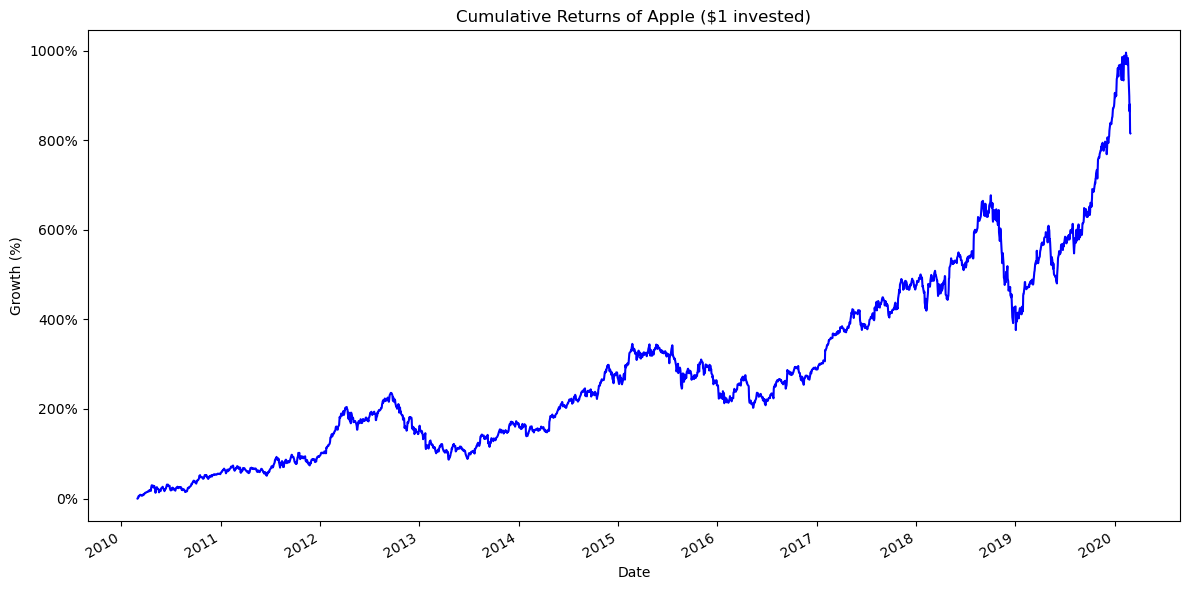

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("downloads/HistoricalQuotes.csv")

# Clean column names
df.columns = df.columns.str.strip()
df.rename(columns={"Close/Last": "Close"}, inplace=True)

# Clean Close column
df["Close"] = (
    df["Close"].astype(str)
    .str.replace(r"[\$,]", "", regex=True)
    .str.strip()
    .astype(float)
)

# Convert Date to datetime, sort, set index
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date"]).sort_values("Date").set_index("Date")

# Calculate Returns 
df["Return"] = df["Close"].pct_change()

#  Calculate Cumulative Returns 
df["Cumulative"] = (1 + df["Return"]).cumprod() - 1

# Plot cumulative returns
plt.figure(figsize=(12,6))
df["Cumulative"].plot(color="blue")

plt.title("Cumulative Returns of Apple ($1 invested)")
plt.ylabel("Growth (%)")
plt.xlabel("Date")

# Format y-axis as percentage
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))

plt.tight_layout()
plt.show()
